In [ ]:
from mlem_nonmpi import get_flist
from torch.nn import functional as F
import torch
import h5py
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
file_list = get_flist("data/srm_file_list.txt")

srms_downsampled = torch.empty((0, 726, 256**2))
for i, filename in enumerate(file_list):
    with h5py.File(filename, "r") as f:
        srms = np.array(f["ppdfs"][:])
        srms = torch.from_numpy(srms)
        srms_downsampled_local = F.interpolate(
            srms.view(1, 726, 512, 512),
            size=(256, 256),
            # mode="trilinear",
            # align_corners=False,
        )
        srms_downsampled_local = srms_downsampled_local.view(1, 726, 256**2)
        srms_downsampled = torch.cat(
            (srms_downsampled, srms_downsampled_local), dim=0
        )
        print(f"Processed layout {i:02d}")
        print(
            f"srms_downsampled memory size: {srms_downsampled.element_size() * srms_downsampled.nelement() / 1024**2:.2f} MB"
        )

In [ ]:
print(f"srms_downsampled shape: {srms_downsampled.shape}")

In [ ]:
torch.save(
    srms_downsampled,
    "data/srms_24x726x256x256.tensor",
)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(
    srms_downsampled[0, 0, :].reshape(256, 256).T,
    origin="lower",
    extent=(-64, 64, -64, 64),
)

In [ ]:
phantom_512x512 = np.load("data/derenzo-phantom_512x512.npy")
phantom_512x512 = torch.from_numpy(phantom_512x512)
phantom_256x256 = F.interpolate(
    phantom_512x512.view(1, 1, 512, 512),
    size=(256, 256),
    # mode="trilinear",
    # align_corners=False,
).view(-1)

In [ ]:
torch.save(
    phantom_256x256,
    "data/derenzo-phantom_256x256.tensor",
)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(
    phantom_256x256.view(256, 256),
    origin="lower",
    extent=(-64, 64, -64, 64),
)
ax.set_aspect("equal")

In [ ]:
# Generate fake projection data

projections = torch.bmm(
    srms_downsampled.view(-1, 726, 256**2).to(dtype=torch.float32),
    phantom_256x256.view(1, 256**2, 1).expand(24, -1, 1).to(dtype=torch.float32),
).squeeze()

In [ ]:
print(f"projections shape: {projections.shape}")

In [ ]:
torch.save(
    projections,
    "data/srm_24x726x256x256_projections.tensor",
)

In [ ]:
def run_one_subiteration_osem(**kwargs) -> torch.Tensor:
    estimate_prev = kwargs["estimate_prev"]
    srms = kwargs["srms"]
    projs = kwargs["projs"]
    ids = kwargs["ids"]
    sfov = estimate_prev.shape[0]
    m = srms[ids].reshape(-1, sfov)
    # forward-projection
    y = torch.matmul(m, estimate_prev)
    # get the corresponding projection data
    p = projs[ids].view(-1)
    # compute the ratio
    r = p / y
    # compute the back-projection
    b = torch.matmul(m.T, r)
    # print(b.shape)
    # compute the matrix sum
    m_sum = torch.sum(m, dim=0)

    x = estimate_prev * b / m_sum
    logp = torch.sum(p * torch.log(torch.matmul(m, x)) - torch.matmul(m, x))
    return x, logp

In [58]:
from rich.progress import Progress, TimeElapsedColumn
import time


columns = [*Progress.get_default_columns(), TimeElapsedColumn()]
progress = Progress(*columns)

sfov = 256**2
n_subsets = 12
sproj = 726

srm_subsets = srms_downsampled.view(n_subsets, -1, sproj, sfov)
projections_subsets = projections.view(n_subsets, -1, sproj)

times = []
log_p = []
output = []

with progress:
    estimate = torch.ones(sfov, dtype=torch.float32)
    task1 = progress.add_task("OSEM Reconstruction", total=2000)
    task2 = progress.add_task("Subsets", total=n_subsets)
    prev_logp = -1000
    diff_logp = 1
    outer_break = False
    while not progress.finished and not outer_break:
        progress.update(task2, completed=0)
        start_time = time.time()
        for j in range(n_subsets):

            estimate, logp = run_one_subiteration_osem(
                estimate_prev=estimate,
                srms=srm_subsets,
                projs=projections_subsets,
                ids=j,
            )
            diff_logp = torch.abs((logp - prev_logp) / prev_logp)
            prev_logp = logp
            progress.update(task2, advance=1)
            if diff_logp < 1e-6:
                progress.update(task1, completed=2000)
                progress.update(task2, completed=n_subsets)
                print("Converged: ", diff_logp)
                outer_break = True
                break
        end_time = time.time()
        time_taken = end_time - start_time
        times.append(time_taken)
        log_p.append(logp)
        output.append(estimate.numpy())
        progress.update(task1, advance=1)

    output = np.array(output)
    times = np.array(times)

Output()

KeyboardInterrupt: 

In [59]:
print(f"Final logp: {logp}")
print(f"Final estimate shape: {estimate.shape}")

Final logp: 3114.42333984375
Final estimate shape: torch.Size([65536])


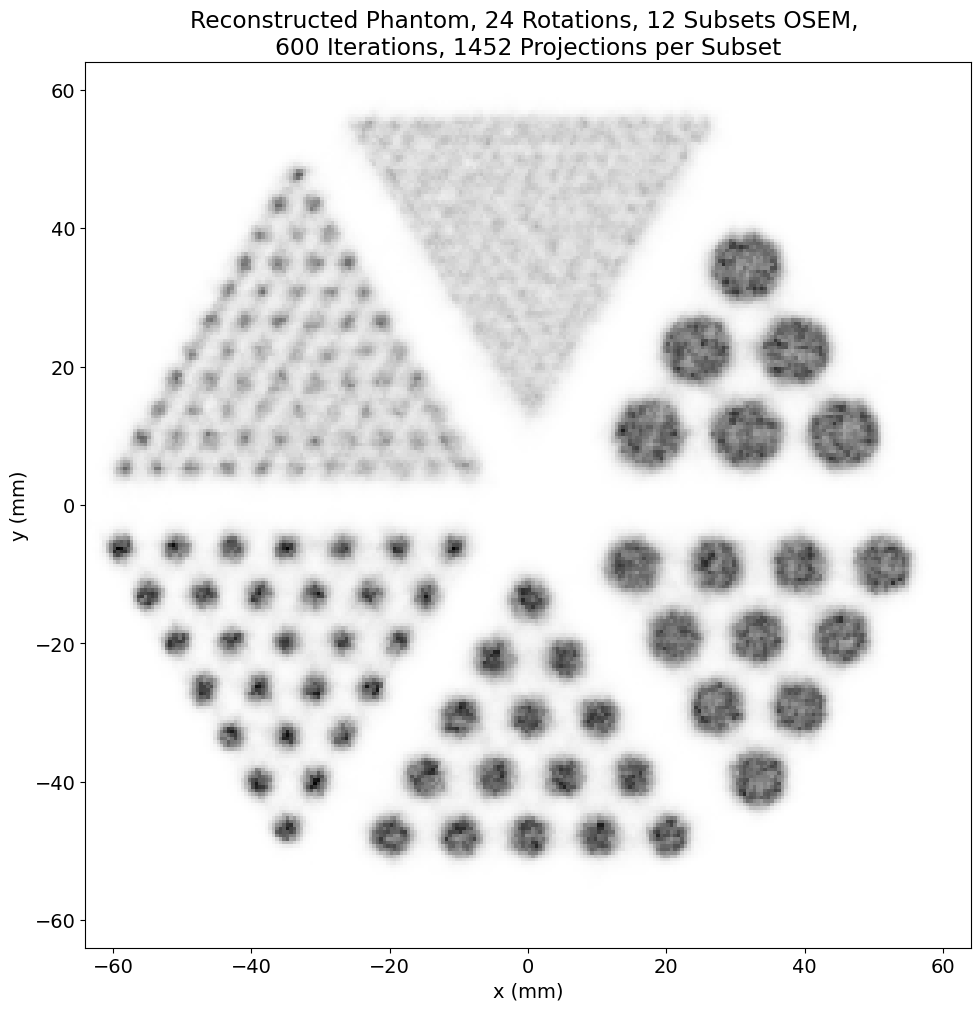

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(11, 10),sharey=True,layout="constrained")
ax.set_title("Reconstructed Phantom, 24 Rotations, 12 Subsets OSEM, \n600 Iterations, 1452 Projections per Subset")
ax.imshow(
    estimate.view(256, 256).T,
    origin="lower",
    cmap="gray_r",
    extent=(-64, 64, -64, 64),
)
ax.set_aspect("equal")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")

plt.savefig("output/recon_osem_24_rotations_no_phantom.png", dpi=300)

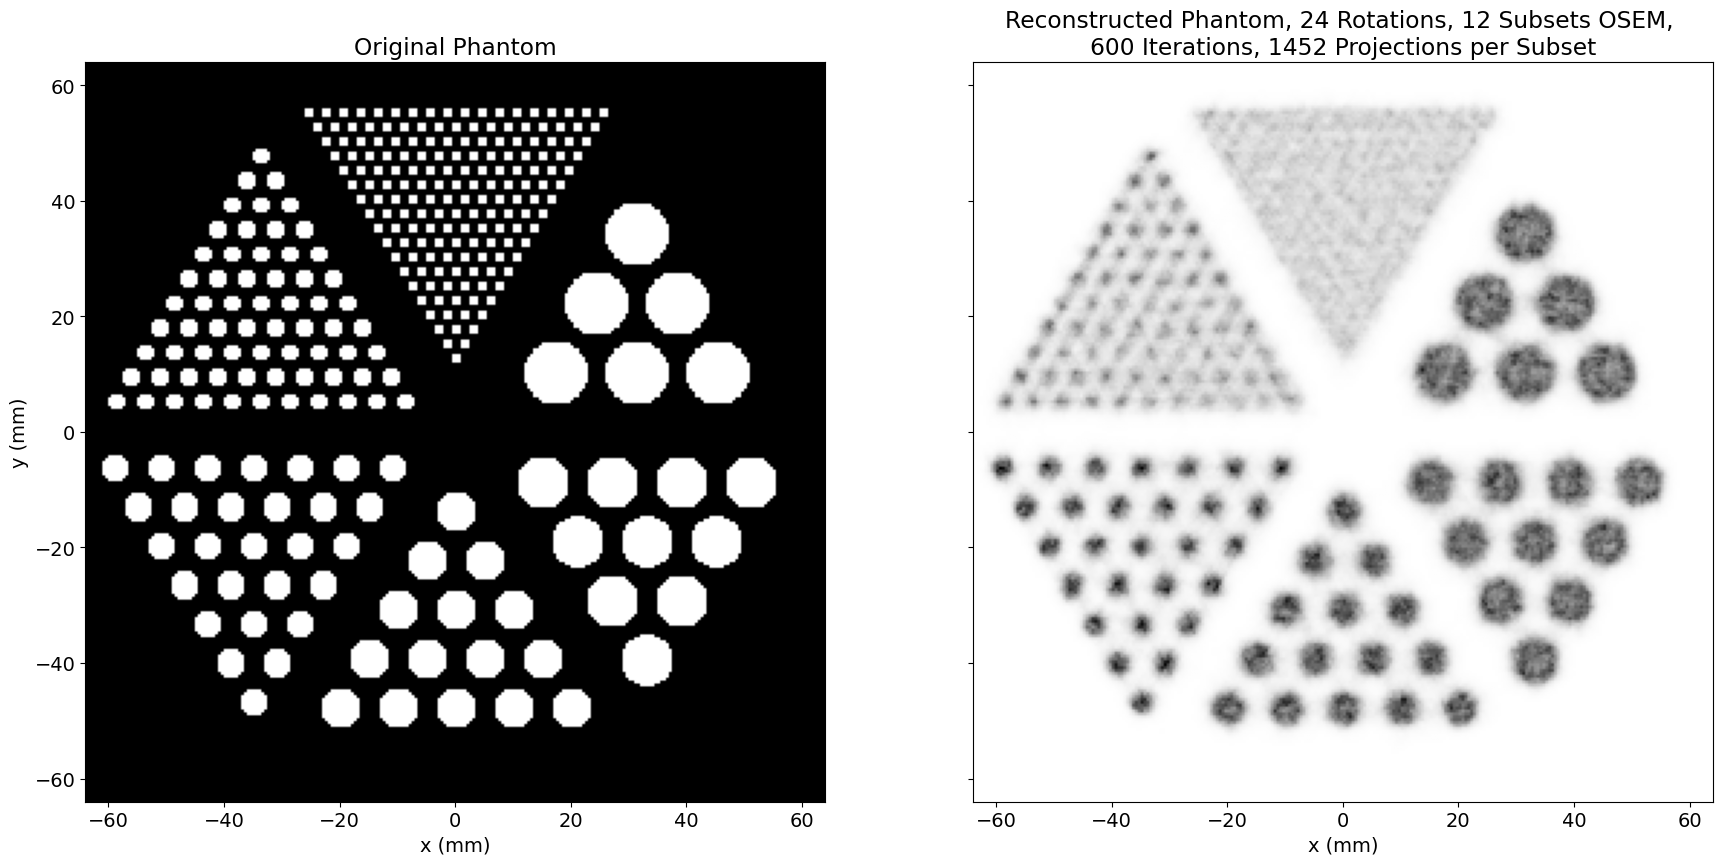

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(21, 10),sharey=True)
axs[0].imshow(
    phantom_256x256.view(256, 256).T,
    origin="lower",
    cmap="gray",
    extent=(-64, 64, -64, 64),
)
axs[0].set_aspect("equal")
axs[0].set_title("Original Phantom")
axs[1].set_title("Reconstructed Phantom, 24 Rotations, 12 Subsets OSEM, \n600 Iterations, 1452 Projections per Subset")
axs[1].imshow(
    estimate.view(256, 256).T,
    origin="lower",
    cmap="gray_r",
    extent=(-64, 64, -64, 64),
)
axs[1].set_aspect("equal")
axs[0].set_xlabel("x (mm)")
axs[1].set_xlabel("x (mm)")
axs[0].set_ylabel("y (mm)")
plt.savefig("output/recon_osem_24_rotations.png", dpi=300)


In [ ]:
from rich.progress import Progress, TimeElapsedColumn
import time


columns = [*Progress.get_default_columns(), TimeElapsedColumn()]
progress = Progress(*columns)

sfov = 256**2
n_subsets = 1
sproj = 726

# srm_subsets = srms_downsampled.view(n_subsets, -1, sproj, sfov)
srm_subsets = srms_downsampled[0].view(1, -1, sproj, sfov)
projections_subsets = projections[0].view(n_subsets, -1, sproj)

times = []
log_p = []
output = []

with progress:
    estimate = torch.ones(sfov, dtype=torch.float32)
    task1 = progress.add_task("OSEM Reconstruction", total=2000)
    task2 = progress.add_task("Subsets", total=n_subsets)
    prev_logp = -1000
    diff_logp = 1
    outer_break = False
    while not progress.finished and not outer_break:
        progress.update(task2, completed=0)
        start_time = time.time()
        for j in range(n_subsets):

            estimate, logp = run_one_subiteration_osem(
                estimate_prev=estimate,
                srms=srm_subsets,
                projs=projections_subsets,
                ids=j,
            )
            diff_logp = torch.abs((logp - prev_logp) / prev_logp)
            prev_logp = logp
            progress.update(task2, advance=1)
            if diff_logp < 1e-6:
                progress.update(task1, completed=1000)
                progress.update(task2, completed=n_subsets)
                print("Converged: ", diff_logp)
                outer_break = True
                break

        end_time = time.time()
        time_taken = end_time - start_time
        times.append(time_taken)
        log_p.append(logp)
        output.append(estimate.numpy())
        progress.update(task1, advance=1)
    output = np.array(output)
    times = np.array(times)

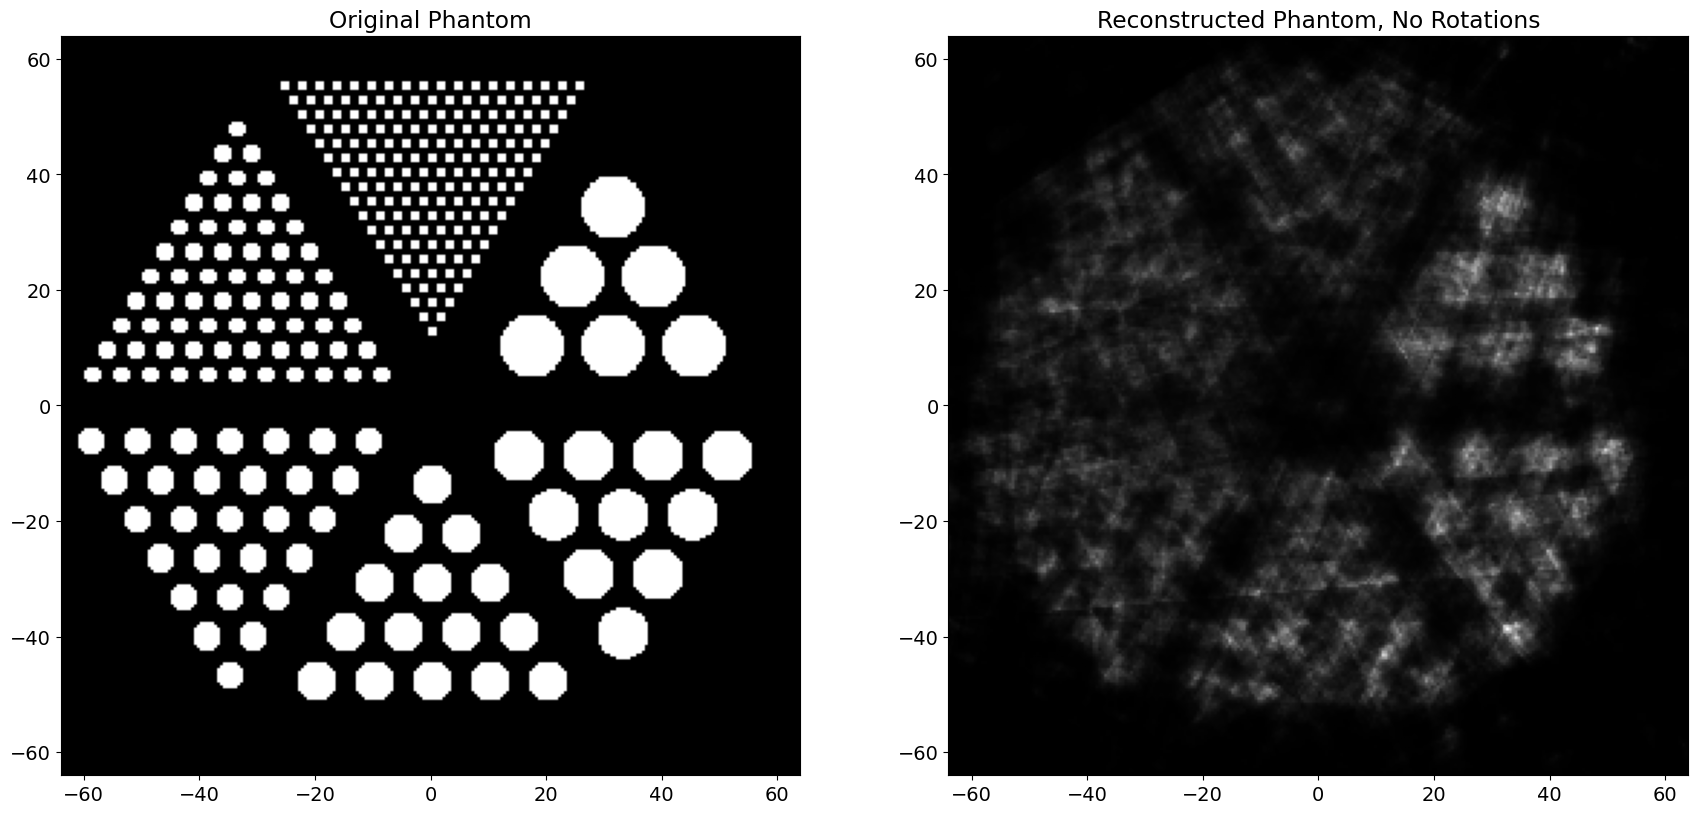

In [57]:
plt.rcParams["font.size"] = 14
fig, axs = plt.subplots(1, 2, figsize=(21, 10))
axs[0].imshow(
    phantom_256x256.view(256, 256).T,
    origin="lower",
    cmap="gray",
    extent=(-64, 64, -64, 64),
)
axs[0].set_aspect("equal")
axs[0].set_title("Original Phantom")
axs[1].set_title("Reconstructed Phantom, No Rotations")
axs[1].imshow(
    estimate.view(256, 256).T,
    origin="lower",
    cmap="gray",
    extent=(-64, 64, -64, 64),
)
axs[1].set_aspect("equal")
plt.savefig("data/recon_no_rotations_256x256.png", dpi=300)